# ***Research Question: How can advanced explainability methods (SHAP, LIME, counterfactual reasoning) be adapted to provide wallet-level risk scores (not only binary labels), offering actionable compliance insights on Elliptic++?***

---
---

The first step of RQ4 was to build a wallet-level AML risk scoring framework using the best-performing model from the previous experiments, namely the balanced Random Forest classifier trained on the Elliptic++ wallet-level dataset.

Unlike traditional AML classification systems that only predict binary licit or illicit labels, the proposed framework converts the predicted fraud probability into a continuous risk score between 0 and 100. This provides more detailed and actionable information for compliance analysts because wallets can now be prioritised according to their estimated AML risk level.

The Random Forest model achieved strong predictive performance on the wallet-level dataset:

- Precision: 85.9\%
- Recall: 70.6\%
- F1-score: 77.5\%
- ROC-AUC: 98.1\%

These results show that the model can effectively distinguish suspicious wallets from normal wallets while maintaining a low false-positive rate.

The generated risk scores were grouped into four compliance-oriented categories:

- Low risk
- Medium risk
- High risk
- Critical risk

This allows the framework to support analyst prioritisation workflows commonly used in AML compliance systems.

In [1]:
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())

Project root: c:\University\Year4\Thesis\AML-Thesis
src exists: True


## **Risk Scoring**

---

In [2]:
from src.risk_scoring import run_wallet_risk_scoring

risk_result = run_wallet_risk_scoring()


=== Wallet Risk Scoring Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216



Wallet risk scores saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\wallet_risk_scoring


## **Shap and Local Shap**

---

In [3]:
from src.xai import run_shap_random_forest

shap_result = run_shap_random_forest(dataset="elliptic-wallets-combined")

=== Random Forest Balanced Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216



=== Classification Report ===


,precision,recall,f1-score,support
0,0.9922,0.9969,0.9946,47382.0000
1,0.8585,0.7060,0.7748,1255.0000
accuracy,0.9894,0.9894,0.9894,0.9894
macro avg,0.9254,0.8514,0.8847,48637.0000
weighted avg,0.9888,0.9894,0.9889,48637.0000



SHAP Random Forest results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq3_xai_models\feature_models\random_forest_shap_elliptic-wallets-combined


In [4]:
from src.xai import run_local_shap_random_forest

local_shap_result = run_local_shap_random_forest()

=== Random Forest Balanced Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216



Local SHAP results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_local_shap_elliptic-wallets-combined


## **Lime**

---

In [5]:
from src.xai import run_lime_random_forest

lime_result = run_lime_random_forest()

=== Random Forest Balanced Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216


c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not 


LIME results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_lime_elliptic-wallets-combined


c:\University\Year4\Thesis\AML-Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## **Counter Factual**

---

In [6]:
from src.xai import run_counterfactual_random_forest

counterfactual_result = run_counterfactual_random_forest()

=== Random Forest Balanced Metrics ===


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,elliptic-wallets-combined,Random Forest balanced,0.989411,0.858527,0.705976,0.774814,0.981216



Counterfactual results saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\feature_models\random_forest_counterfactual_elliptic-wallets-combined


## **Compliance Output**

---

In [7]:
from src.risk_scoring import build_compliance_output, save_compliance_output

compliance_df = build_compliance_output(
    risk_scores_df=risk_result["risk_scores"],
    shap_df=shap_result["importance"],
    lime_df=lime_result["lime_explanations"],
    counterfactual_df=counterfactual_result["counterfactuals"],
    top_n_explanations=3,
)

save_compliance_output(compliance_df)

compliance_df.head(10)

Compliance output saved to: C:\University\Year4\Thesis\AML-Thesis\models\rq4_risk_scoring\wallet_risk_scoring\compliance_output.csv


,wallet_index,true_label,predicted_label,fraud_probability,risk_score,risk_level,recommended_action,top_shap_drivers,top_lime_drivers,counterfactual_recommendation
200663,200663,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_mean > 0.01; fees_median > 0.01; blocks_b...,Changing blocks_btwn_txs_max from 1.0 to 0.0 r...
200781,200781,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,transacted_w_address_min <= 1.00; fees_mean > ...,Changing blocks_btwn_txs_max from 4.0 to 0.0 r...
200792,200792,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_sent_block > 449664.00; first_received_b...,Changing blocks_btwn_txs_median from 6.0 to 0....
197154,197154,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_as_share_median > 0.00; fees_as_share_min...,Changing fees_median from 0.0002 to 0.00180925...
197156,197156,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing lifetime_in_blocks from 3.0 to 0.0 re...
197225,197225,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_sent_block > 449664.00; fees_as_share_ma...,Changing btc_received_total from 0.0049 to 0.0...
205563,205563,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing lifetime_in_blocks from 1.0 to 0.0 re...
195298,195298,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,fees_as_share_median > 0.00; fees_as_share_min...,Changing fees_as_share_total from 0.0003442433...
205577,205577,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,1.00 < transacted_w_address_total <= 2.00; fee...,Changing fees_min from 0.0001 to 0.0015755 red...
205660,205660,1,1,1.0,100.0,Critical,Prioritize for compliance investigation,transacted_w_address_total; first_sent_block; ...,first_received_block > 453697.00; first_sent_b...,Changing num_txs_as_sender from 1.0 to 0.0 red...


### **Loaders**

---

In [8]:
import matplotlib.pyplot as plt

BASE_DIR = Path("../models/rq4_risk_scoring")

PATHS = {
    "risk_scores": BASE_DIR / "wallet_risk_scoring" / "wallet_risk_scores.csv",
    "local_shap": BASE_DIR / "feature_models" / "random_forest_local_shap_elliptic-wallets-combined" / "local_shap_explanations.csv",
    "lime": BASE_DIR / "feature_models" / "random_forest_lime_elliptic-wallets-combined" / "lime_explanations.csv",
    "counterfactuals": BASE_DIR / "feature_models" / "random_forest_counterfactual_elliptic-wallets-combined" / "counterfactual_explanations.csv",
    "statistical": BASE_DIR / "statistical_analysis",
    "figures": BASE_DIR / "figures",
}

PATHS["statistical"].mkdir(parents=True, exist_ok=True)
PATHS["figures"].mkdir(parents=True, exist_ok=True)

risk_scores = pd.read_csv(PATHS["risk_scores"])
local_shap = pd.read_csv(PATHS["local_shap"])
lime = pd.read_csv(PATHS["lime"])
counterfactuals = pd.read_csv(PATHS["counterfactuals"])

print("Saved results loaded successfully.")

Saved results loaded successfully.


## **Behavioural Pattern Analysis**

---

In [9]:
pattern_map = {
    "Fee behaviour": [
        "fees_min", "fees_max", "fees_mean", "fees_median", "fees_total",
        "fees_as_share_min", "fees_as_share_max", "fees_as_share_mean",
        "fees_as_share_median", "fees_as_share_total"
    ],
    "Transaction timing": [
        "blocks_btwn_txs_min", "blocks_btwn_txs_max", "blocks_btwn_txs_mean",
        "blocks_btwn_txs_median", "lifetime_in_blocks"
    ],
    "Counterparty interaction": [
        "transacted_w_address_total"
    ],
    "Temporal blockchain activity": [
        "first_sent_block", "first_received_block",
        "first_block_appeared_in", "last_block_appeared_in"
    ],
    "BTC transfer behaviour": [
        "btc_sent_min", "btc_sent_max", "btc_sent_mean", "btc_sent_median", "btc_sent_total",
        "btc_received_min", "btc_received_max", "btc_received_mean",
        "btc_received_median", "btc_received_total"
    ],
    "Transaction volume": [
        "total_txs", "num_txs_as_sender", "num_txs_as_receiver"
    ]
}

def map_pattern(feature_name):
    feature_name = str(feature_name)

    for pattern, features in pattern_map.items():
        for feature in features:
            if feature in feature_name:
                return pattern

    return "Other"

### **Local Shap - Behavioural Pattern**

---

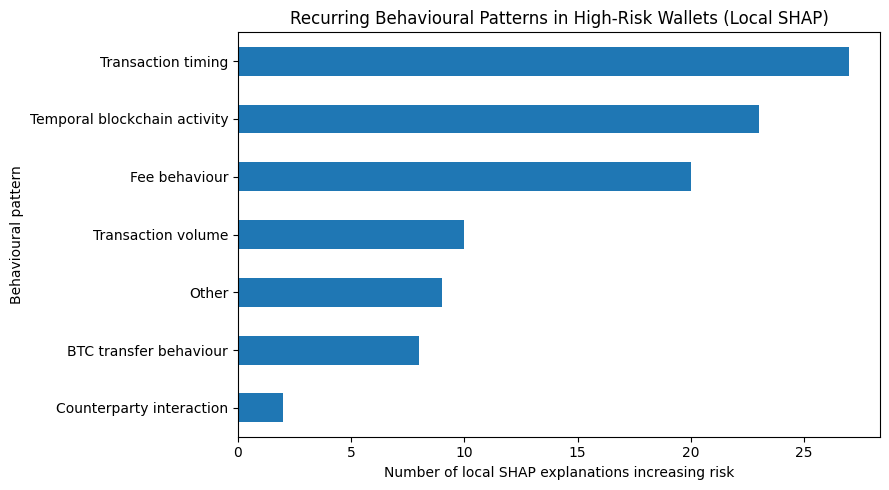

behaviour_pattern
Transaction timing              27
Temporal blockchain activity    23
Fee behaviour                   20
Transaction volume              10
Other                            9
BTC transfer behaviour           8
Counterparty interaction         2
dtype: int64

In [10]:
local_shap["behaviour_pattern"] = local_shap["feature"].apply(map_pattern)

shap_patterns = (
    local_shap[local_shap["direction"] == "increases risk"]
    .groupby("behaviour_pattern")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
shap_patterns.plot(kind="barh")
plt.xlabel("Number of local SHAP explanations increasing risk")
plt.ylabel("Behavioural pattern")
plt.title("Recurring Behavioural Patterns in High-Risk Wallets (Local SHAP)")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_local_shap_elliptic-wallets-combined/local_shap_behavioural_patterns.png", dpi=150)
plt.show()

shap_patterns.sort_values(ascending=False)

### **Local SHAP Behavioural Pattern Analysis**
---

The **local SHAP analysis** was used to identify the **most common behavioural patterns** that increase **AML risk** in **high-risk wallets**. Instead of focusing only on global feature importance, **local SHAP explanations** provide **wallet-level explanations** by showing which behavioural characteristics contribute most strongly to the predicted risk score of individual wallets.

The results show that **transaction timing** is the **most frequent behavioural pattern** associated with increased AML risk. Features related to the **time difference between transactions** and **wallet lifetime** appeared most often in the local SHAP explanations. This suggests that suspicious wallets tend to perform transactions in **concentrated or unusual time periods**, which may indicate **rapid fund movement** or **laundering activity**.

**Temporal blockchain activity** was the **second strongest behavioural pattern**. Features such as ***first_sent_block***, ***first_received_block***, and **wallet appearance timing** repeatedly contributed to higher risk scores. This indicates that the period in which a wallet becomes active on the blockchain is an **important factor for AML detection**.

**Fee behaviour** also appeared frequently in the local SHAP explanations. Features related to **transaction fees** and **fee proportions** consistently increased wallet risk scores. This suggests that suspicious wallets often exhibit **unusual fee structures**, which may reflect attempts to prioritise **fast transaction processing** or move funds quickly through the network.

**Transaction volume** and **BTC transfer behaviour** also contributed to AML risk, although they appeared less frequently than the previous patterns. These results indicate that some suspicious wallets show **abnormal transaction activity** or **unusual BTC transfer patterns**.

Finally, **counterparty interaction** appeared only a small number of times in the local SHAP explanations. This suggests that the number of interacted addresses is **less important** at the local wallet level compared to **timing** and **fee-related behavioural patterns**.

Overall, the local SHAP analysis demonstrates that **high-risk wallets** are mainly characterised by **abnormal transaction timing**, **temporal blockchain activity**, and **unusual fee behaviour**. These results provide **interpretable wallet-level explanations** that can help compliance analysts understand why specific wallets are considered suspicious.

### **Lime - Behavioural Pattern**

---

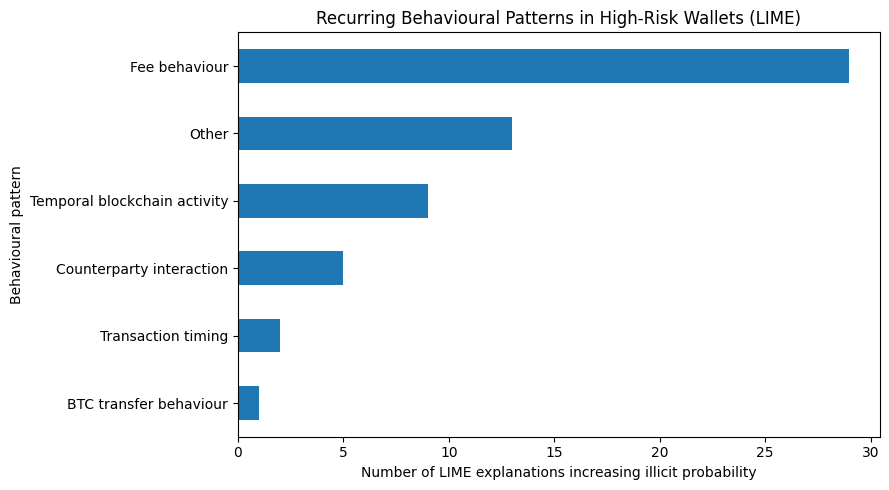

behaviour_pattern
Fee behaviour                   29
Other                           13
Temporal blockchain activity     9
Counterparty interaction         5
Transaction timing               2
BTC transfer behaviour           1
dtype: int64

In [11]:
lime["behaviour_pattern"] = lime["feature_rule"].apply(map_pattern)

lime_patterns = (
    lime[lime["lime_importance"] > 0]
    .groupby("behaviour_pattern")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
lime_patterns.plot(kind="barh")
plt.xlabel("Number of LIME explanations increasing illicit probability")
plt.ylabel("Behavioural pattern")
plt.title("Recurring Behavioural Patterns in High-Risk Wallets (LIME)")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_lime_elliptic-wallets-combined/lime_behavioural_patterns.png", dpi=150)
plt.show()

lime_patterns.sort_values(ascending=False)

### **LIME Behavioural Pattern Analysis**
---

The **LIME analysis** was used to provide **local and interpretable explanations** for individual wallet predictions. Similar to the **local SHAP analysis**, the goal was to identify which behavioural patterns most frequently increase the predicted illicit probability of **high-risk wallets**.

The results show that **fee behaviour** is the **strongest behavioural pattern** identified by LIME. Features related to **transaction fees** and **fee proportions** appeared much more frequently than any other behavioural group. This indicates that **abnormal fee structures** are one of the most important indicators of suspicious wallet activity. High transaction fees or unusual fee distributions may reflect attempts to prioritise **fast transaction processing** or rapidly move funds through the blockchain network.

**Temporal blockchain activity** was the **second most common behavioural pattern**. Features related to the timing of wallet activity, such as the **first transaction blocks** and **wallet appearance periods**, repeatedly contributed to higher illicit probabilities. This suggests that the time period in which wallets become active plays an **important role in AML detection**.

**Counterparty interaction** also appeared in several LIME explanations. This indicates that wallets interacting with a **large number of addresses** may exhibit suspicious behaviour associated with **layering** or **fund distribution activities**.

In contrast to the local SHAP analysis, **transaction timing** and **BTC transfer behaviour** appeared less frequently in the LIME explanations. This difference is expected because **SHAP and LIME use different explanation strategies**. SHAP measures feature contribution based on **cooperative game theory**, while LIME approximates local decision boundaries using **simplified local models**.

Despite these differences, both explanation methods consistently identified **fee-related behaviour** and **temporal blockchain activity** as important drivers of **wallet AML risk**. This agreement between explanation methods increases the **reliability** and **interpretability** of the proposed risk-scoring framework.

Overall, the LIME analysis shows that suspicious wallets are mainly characterised by **abnormal fee behaviour**, **temporal blockchain activity**, and **high interaction with other blockchain addresses**. These explanations provide **useful wallet-level insights** that can support **AML compliance investigations** and **analyst decision-making**.

### **Counterfactuals - Behavioural Pattern**

---

In [12]:
counterfactuals["behaviour_pattern"] = counterfactuals["feature_changed"].apply(map_pattern)

cf_patterns = (
    counterfactuals
    .groupby("behaviour_pattern")["risk_score_reduction"]
    .agg(["count", "mean", "max"])
    .sort_values("mean", ascending=False)
)

cf_patterns

,count,mean,max
behaviour_pattern,,,
BTC transfer behaviour,2,98.750000,99.0
Transaction timing,8,90.812500,93.0
Other,2,87.250000,88.5
Temporal blockchain activity,11,84.727273,98.0
Transaction volume,2,84.500000,98.5
Fee behaviour,25,77.440000,98.0


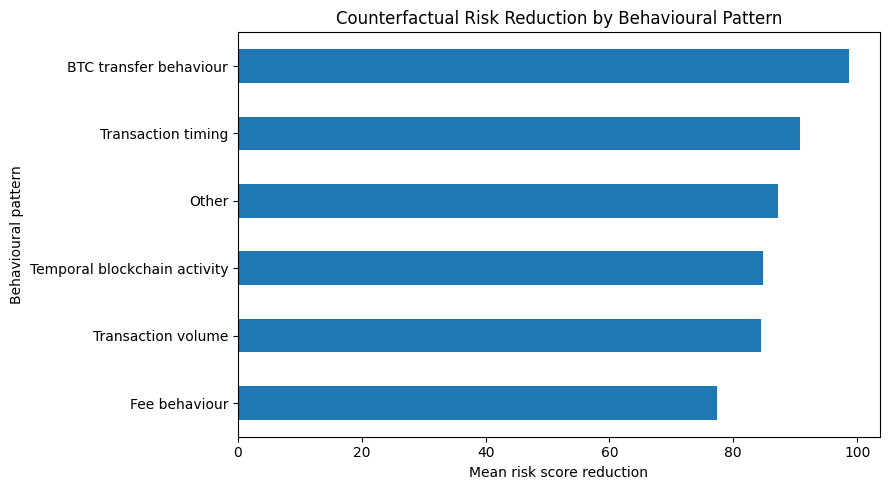

In [13]:
cf_patterns_plot = cf_patterns["mean"].sort_values(ascending=True)

plt.figure(figsize=(9, 5))
cf_patterns_plot.plot(kind="barh")
plt.xlabel("Mean risk score reduction")
plt.ylabel("Behavioural pattern")
plt.title("Counterfactual Risk Reduction by Behavioural Pattern")
plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/feature_models/random_forest_counterfactual_elliptic-wallets-combined/counterfactual_behavioural_patterns.png", dpi=150)
plt.show()

### **Counterfactual Behavioural Pattern Analysis**
---

The **counterfactual analysis** was used to identify which behavioural changes can most strongly reduce the predicted **AML risk score** of **high-risk wallets**. Unlike **SHAP** and **LIME**, which explain why a wallet is considered suspicious, **counterfactual reasoning** provides **actionable compliance insights** by showing how modifying specific behavioural patterns changes the predicted risk score.

The results show that **BTC transfer behaviour** produces the **largest average reduction** in wallet risk scores. Although this behavioural pattern appeared less frequently than other groups, modifying **BTC transfer-related features** resulted in an average risk reduction of **98.75 points**. This indicates that **large or abnormal BTC transfer behaviour** can have a very strong influence on AML risk predictions for certain wallets.

**Transaction timing** was the **second strongest behavioural pattern** in terms of average risk reduction. Features related to the **timing and spacing of transactions** produced an average reduction of **90.81 points**. This suggests that **concentrated transaction activity** and **unusual transaction timing** strongly contribute to suspicious wallet behaviour.

**Temporal blockchain activity** also showed a strong impact on wallet risk scores. Modifying features related to **wallet activation periods** and **blockchain timing** reduced the predicted risk score by an average of **84.73 points**. This confirms the importance of **temporal behaviour** for wallet-level AML detection.

**Fee behaviour** appeared **most frequently** in the counterfactual explanations, with a total of **25 occurrences**. Although the average reduction was lower than BTC transfer behaviour and transaction timing, **fee-related behavioural changes** still reduced wallet risk scores by an average of **77.44 points**. This demonstrates that **abnormal fee structures** are one of the most stable and consistent indicators of suspicious wallet activity.

**Transaction volume** also contributed to substantial risk reductions, while other behavioural groups produced smaller but still meaningful effects.

Overall, the counterfactual analysis demonstrates that **relatively small behavioural changes** can significantly reduce predicted wallet AML risk. The results also show that the proposed framework can provide **actionable compliance insights** by identifying which behavioural characteristics contribute most strongly to suspicious wallet activity and how these behaviours could be modified to reduce AML risk.

### **Combined Patterns**

---

In [14]:
combined_patterns = pd.DataFrame({
    "local_shap_count": shap_patterns,
    "lime_count": lime_patterns,
    "counterfactual_count": cf_patterns["count"],
    "mean_counterfactual_reduction": cf_patterns["mean"],
}).fillna(0)

combined_patterns = combined_patterns.sort_values(
    ["local_shap_count", "lime_count", "mean_counterfactual_reduction"],
    ascending=False
)

combined_patterns.to_csv(
    BASE_DIR / "combined_patterns.csv",
    index=True
)

combined_patterns

,local_shap_count,lime_count,counterfactual_count,mean_counterfactual_reduction
behaviour_pattern,,,,
Transaction timing,27,2.0,8.0,90.812500
Temporal blockchain activity,23,9.0,11.0,84.727273
Fee behaviour,20,29.0,25.0,77.440000
Transaction volume,10,0.0,2.0,84.500000
Other,9,13.0,2.0,87.250000
BTC transfer behaviour,8,1.0,2.0,98.750000
Counterparty interaction,2,5.0,0.0,0.000000


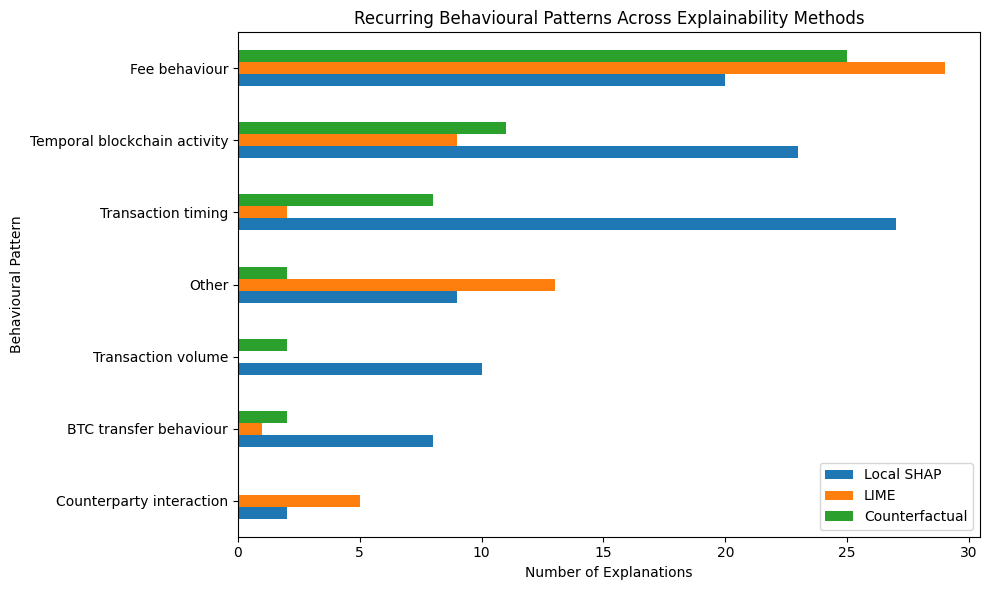

In [34]:
import matplotlib.pyplot as plt

# Select columns for plotting
plot_df = combined_patterns[
    ["local_shap_count", "lime_count", "counterfactual_count"]
].copy()

# Sort by overall importance
plot_df["total"] = plot_df.sum(axis=1)
plot_df = plot_df.sort_values("total", ascending=True)

# Remove helper column
plot_df = plot_df.drop(columns="total")

# Plot
ax = plot_df.plot(
    kind="barh",
    figsize=(10, 6),
)

plt.xlabel("Number of Explanations")
plt.ylabel("Behavioural Pattern")
plt.title("Recurring Behavioural Patterns Across Explainability Methods")
plt.legend([
    "Local SHAP",
    "LIME",
    "Counterfactual"
])

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/figures/combined_behavioural_patterns.png", dpi=150)
plt.show()

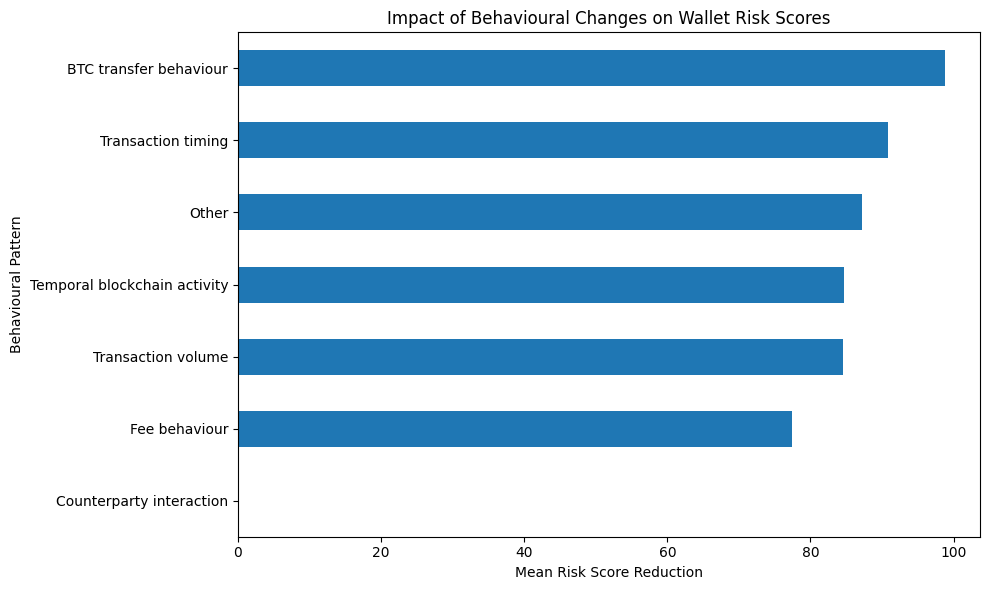

In [37]:
import matplotlib.pyplot as plt

# Sort by mean reduction
impact_plot = combined_patterns[
    "mean_counterfactual_reduction"
].sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))

impact_plot.plot(kind="barh")

plt.xlabel("Mean Risk Score Reduction")
plt.ylabel("Behavioural Pattern")
plt.title("Impact of Behavioural Changes on Wallet Risk Scores")

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/figures/behavioural_impact_changes_wallet_risk_scores.png", dpi=150)
plt.show()

### **Overall Results:**
---

The **combined behavioural pattern analysis** integrates the results from **local SHAP**, **LIME**, and **counterfactual reasoning** in order to identify the most consistent behavioural characteristics associated with **high-risk wallets**.

The results show that **transaction timing** is the **strongest behavioural pattern** identified by local SHAP explanations. This pattern appeared **27 times** and also produced a large average counterfactual risk reduction of **90.81 points**. These findings suggest that suspicious wallets often perform transactions within **abnormal or concentrated time periods**. Features related to **transaction spacing** and **wallet lifetime** therefore play an important role in **wallet-level AML detection**.

**Temporal blockchain activity** was another highly important behavioural group across all explanation methods. It appeared frequently in both **SHAP** and **LIME** explanations and also produced **large counterfactual risk reductions**. This indicates that the time period in which wallets become active on the blockchain strongly influences **AML risk predictions**.

**Fee behaviour** showed the **highest overall consistency** across the different explainability methods. It appeared **20 times** in local SHAP explanations, **29 times** in LIME explanations, and **25 times** in counterfactual explanations. Although its average counterfactual reduction was lower than transaction timing and BTC transfer behaviour, **fee-related features** were the most stable and repeatedly identified indicators of **suspicious wallet activity**.

**BTC transfer behaviour** appeared less frequently than other behavioural groups, but it produced the **highest average counterfactual risk reduction** of **98.75 points**. This means that although BTC transfer behaviour is not the most common suspicious pattern, it can have an **extremely large influence** on the predicted AML risk score for some wallets.

**Transaction volume** also contributed to wallet risk predictions, especially in the local SHAP explanations, while **counterparty interaction** appeared less frequently overall. This suggests that **timing** and **fee-related behaviours** are more important for wallet-level AML detection than simple interaction counts.

Overall, the combined analysis demonstrates that the different explainability methods identify **similar behavioural characteristics** associated with suspicious wallet activity. The agreement between **SHAP**, **LIME**, and **counterfactual reasoning** increases the **reliability** of the proposed framework and shows that wallet-level AML risk can be explained through **interpretable behavioural patterns** rather than only binary classification outputs.

## **Statistical Analysis**

---

In [17]:
import pandas as pd

risk_scores = pd.read_csv(
    "../models/rq4_risk_scoring/wallet_risk_scoring/wallet_risk_scores.csv"
)

# Split by class
licit_scores = risk_scores[risk_scores["true_label"] == 0]["risk_score"]
illicit_scores = risk_scores[risk_scores["true_label"] == 1]["risk_score"]

# Summary statistics
stats_df = pd.DataFrame({
    "licit": [
        licit_scores.mean(),
        licit_scores.median(),
        licit_scores.std(),
        licit_scores.min(),
        licit_scores.max(),
    ],
    "illicit": [
        illicit_scores.mean(),
        illicit_scores.median(),
        illicit_scores.std(),
        illicit_scores.min(),
        illicit_scores.max(),
    ]
}, index=[
    "mean",
    "median",
    "std",
    "min",
    "max",
])

stats_df.to_csv("../models/rq4_risk_scoring/statistical_analysis/compared_risk_scores.csv")

stats_df

,licit,illicit
mean,1.615606,69.152816
median,0.000000,88.000000
std,5.684430,35.271837
min,0.000000,0.000000
max,98.000000,100.000000


### **Mann–Whitney U test**

---

In [18]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    illicit_scores,
    licit_scores,
    alternative="greater"
)

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"p-value: {p_value:.10e}")

Mann-Whitney U statistic: 58347432.0000
p-value: 0.0000000000e+00


### **Risk-level distribution**

---

In [19]:
risk_distribution = (
    risk_scores["risk_level"]
    .value_counts()
    .sort_index()
)

risk_distribution.to_csv("../models/rq4_risk_scoring/statistical_analysis/risk_distribution.csv")

risk_distribution

risk_level
Critical      783
High          256
Low         47060
Medium        538
Name: count, dtype: int64

<Figure size 700x500 with 0 Axes>

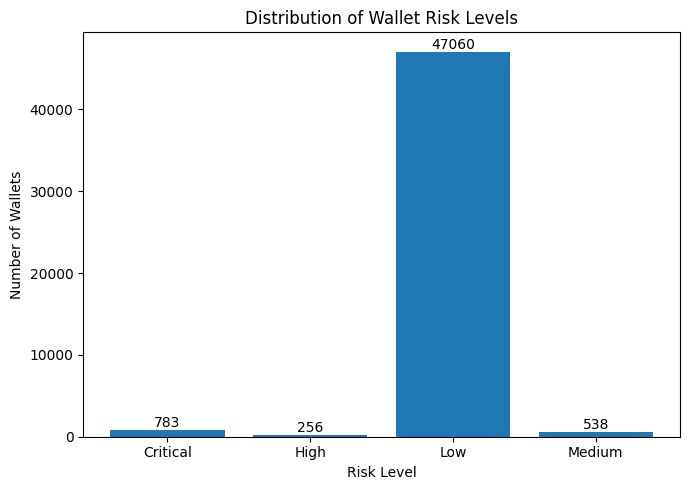

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

risk_distribution_dr = pd.read_csv(
    PATHS["statistical"] / "risk_distribution.csv"
)

x = risk_distribution_dr["risk_level"]
y = risk_distribution_dr["count"]

plt.figure(figsize=(7, 5))
plt.bar(x, y)

for i, value in enumerate(y):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("Number of Wallets")
plt.xlabel("Risk Level")
plt.title("Distribution of Wallet Risk Levels")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    PATHS["statistical"] / "wallet_risk_distribution.png",
    dpi=150
)
plt.show()

### **Correlation Analysis**

---

In [21]:
important_features = [
    "fees_max",
    "blocks_btwn_txs_max",
    "transacted_w_address_total",
    "first_sent_block",
    "btc_sent_total",
]

correlation_df = risk_scores[
    important_features + ["risk_score"]
].corr()

correlation_df.to_csv("../models/rq4_risk_scoring/statistical_analysis/correlation.csv")

correlation_df["risk_score"].sort_values(ascending=False)

risk_score                    1.000000
first_sent_block              0.208104
fees_max                      0.059620
btc_sent_total               -0.001696
transacted_w_address_total   -0.013808
blocks_btwn_txs_max          -0.019640
Name: risk_score, dtype: float64

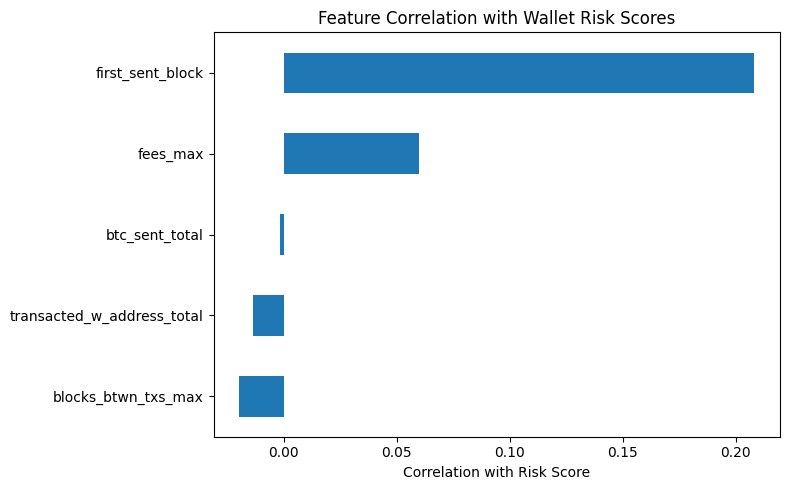

In [22]:
import matplotlib.pyplot as plt

correlation_df = pd.read_csv(
    PATHS["statistical"] / "correlation.csv",
    index_col=0
)

corr_values = correlation_df["risk_score"][:-1].sort_values()

plt.figure(figsize=(8, 5))

corr_values.plot(kind="barh")

plt.xlabel("Correlation with Risk Score")
plt.title("Feature Correlation with Wallet Risk Scores")

plt.tight_layout()
plt.savefig("../models/rq4_risk_scoring/statistical_analysis/feature_wallet_risk_correlation.png")
plt.show()

### **Statistical Analysis of Wallet Risk Scores**
---


The **statistical analysis** further validates the effectiveness of the proposed **wallet risk scoring framework**.

The descriptive statistics show a **very large difference** between **licit** and **illicit wallet risk scores**. Licit wallets have a **mean risk score of only 1.62**, while illicit wallets have a much higher **mean score of 69.15**. The median values also show a **strong separation** between the two groups, with licit wallets having a **median risk score of 0** and illicit wallets having a **median score of 88**.

In addition, the **standard deviation** for illicit wallets is much larger than for licit wallets. This indicates that suspicious wallets show **more diverse behavioural patterns** and different levels of AML risk. Some illicit wallets receive **moderate risk scores**, while others are classified as **extremely high risk**.

The **Mann–Whitney U statistical test** was used to evaluate whether the difference between licit and illicit wallet risk scores is **statistically significant**. The test produced a **very large U statistic** and a **p-value close to zero**. Since the p-value is far below the significance threshold of **0.05**, the **null hypothesis can be rejected**. This confirms that illicit wallets have **significantly higher risk scores** than licit wallets.

The **risk-level distribution** also demonstrates that most wallets in the dataset are classified as **low risk**. However, the framework still identified a meaningful number of **medium, high, and critical-risk wallets**. In total, **783 wallets** were classified as **critical risk** and **256 wallets** were classified as **high risk**. This shows that the proposed framework is capable of **separating highly suspicious wallets** from the majority of normal blockchain activity.

The **correlation analysis** was performed to examine the relationship between important wallet features and the final risk score. The feature ***first_sent_block*** showed the **strongest positive correlation** with wallet risk score, suggesting that the **timing of wallet activity** plays an important role in AML risk prediction. The feature ***fees_max*** also showed a **positive relationship** with the risk score, although the correlation was weaker.

Other features such as ***btc_sent_total***, ***transacted_w_address_total***, and ***blocks_btwn_txs_max*** showed **very small or slightly negative correlations**. This suggests that **individual behavioural features alone are not sufficient** to explain suspicious activity. Instead, the **Random Forest model combines multiple behavioural signals together** to produce the final wallet risk score.

Overall, the statistical analysis confirms that the proposed **AML risk scoring framework** successfully separates **licit and illicit wallets** and produces **meaningful wallet-level risk assessments** supported by **statistically significant results**.

## ***Research Question: How can advanced explainability methods (SHAP, LIME, counterfactual reasoning) be adapted to provide wallet-level risk scores (not only binary labels), offering actionable compliance insights on Elliptic++?***
---

The results of this study show that **advanced explainability methods** can be successfully adapted to provide **wallet-level AML risk scores** instead of only binary **licit or illicit classifications** on the **Elliptic++ dataset**.

First, the **Random Forest model** was extended from **binary classification** to **continuous risk scoring** by converting prediction probabilities into **wallet risk scores between 0 and 100**. This allowed the framework to estimate the **severity of suspicious behaviour** instead of only predicting whether a wallet is illicit or not.

**SHAP explanations** were then used to identify the most important behavioural features influencing wallet risk scores. The results showed that **transaction timing**, **temporal blockchain activity**, and **fee-related behaviour** were the **strongest indicators of suspicious activity**. **Local SHAP explanations** also provided **wallet-specific explanations**, making the model outputs easier to interpret for compliance analysts.

**LIME explanations** complemented SHAP by providing **simplified local explanations** for individual wallet predictions. The results showed that **fee behaviour** was consistently identified as an important behavioural pattern across many **high-risk wallets**. This demonstrates that **local explainability methods** can provide understandable compliance insights even for complex machine learning models.

**Counterfactual reasoning** further improved interpretability by showing how changes in wallet behaviour could **reduce predicted AML risk scores**. The analysis revealed that **BTC transfer behaviour** and **transaction timing** produced the **largest average reductions** in risk scores. This provides **actionable compliance insights** because investigators can identify which wallet behaviours contribute most strongly to suspicious activity.

The **statistical analysis** confirmed that the proposed framework successfully separates **licit and illicit wallets**. Illicit wallets received **significantly higher risk scores** than licit wallets, and the **Mann–Whitney U test** showed that the difference was **statistically significant**.

Overall, the study demonstrates that **SHAP**, **LIME**, and **counterfactual reasoning** can be adapted into a **unified explainable AML framework** that produces **interpretable wallet-level risk scores**, **behavioural explanations**, and **actionable compliance insights** for blockchain investigation on **Elliptic++**.